# Calibrating competition between pairs of species

## Advices from the user guide :

> It is prudent to test the competitive behavior of pairs of species to ensure that the behavior is appropriate. I recommend that you conduct some tests of two and/or three species combinations using your calibration setup to ensure that species compete as you would expect. Extremely poor competitive ability usually results only when a cohort is inappropriately overtopped by another and becomes lightstarved. Some users conduct tests (or even calibrate concurrently) on different soil types, which is especially useful for checking growth under waterlogged and drought conditions. Small tweaks to the H parameters can often greatly improve performance on those soils while having little effect on performance on the mesic soil. Anomalies can be corrected with modest tweaks of one or two parameters to ensure that the cohorts grow sufficiently similar to remain in the same canopy layer. You can also adjust the LayerThreshRatio parameters if needed to achieve desired canopy layering behavior. The currently recommended value is 0.5, but you may find that another value is better (e.g., 0.67).

> Again, to ensure realistic competition, it is advisable to use common parameter values across species as much as possible, unless you have empirical data that are comparable and reliable across species. If you are planning to experimentally vary some parameters, holding the others constant will improve the signal from your experiment.

> Minimizing species differences in parameters such as SLWDel, PsnAgeRed, k, MaintResp, DNSC and FracBelowG, will make competitive interactions more predictable. Hold these as close to each other as possible, varying other parameters to calibrate as much as possible within empirical limits. However, when you cannot calibrate adequately using the common parameter values, do not hesitate to vary the one or two other parameters that will produce good performance. It is very likely that such modifications reflect biological reality. 2) Use the PnET-Succession function worksheet to help you understand how the parameters determine the behavior of cohort state variables as a function of the abiotic inputs, both intermediate variables and the ones that ultimately reflect competition and growth (e.g., NetPsn, foliar and wood biomass, NSCfrac). It is available from the PnET-Succession page of the LANDIS-II website (www.landis-ii.org). 3) It is highly recommended that you verify your calibrations by simulating several similar species together to ensure that they in fact compete as expected. If not, often a slight tweak of one parameter can bring them in line with expectations.

> To produce predictable competitive interactions that can be controlled by intuitive modification of a small number of parameters for individual species, it is helpful to use common parameter values across all species whenever possible. These can be conveniently maintained (and modified as necessary) in the GenericPnETSpeciesParameters file. Other parameters vary by life history trait or growth form, and each species having a particular life history trait should have the same (or similar) parameter value to represent that trait. Examples of such traits include shade tolerance (HalfSat), drought tolerance (H3 & H4), extinction coefficient (k), relationship between foliar N and photosynthetic capacity (AmaxA and AmaxB), leaf weight change by canopy position (SLWdel) and fraction of foliar biomass relative to active wood biomass (FracFol). Parameters that the model is highly sensitive to (for which common values should be used as much as possible) include: MaintResp, AmaxA, AmaxB, k, and FracBelowG.

> MaintResp is a critical parameter for PnET-Succession because it is the primary determinant of cohort growth limitations and death, and growth is highly sensitive to variation in this parameter. Unfortunately, this parameter is rarely known empirically in the units used by the model, so it must be calibrated. If MaintResp is too low, cohorts will never die from stress and growth will be virtually unconstrained. If MaintResp is too high, growth will quickly level off because of high maintenance costs and cohorts will be highly susceptible to stress. For most studies, competitive outcomes should be a function of competition for light and water, not from a difference in maintenance costs. Therefore, it is recommended to find a value for MaintResp that works across life history traits and growth forms. This is fairly easily done. Choose some representative species having generic growth parameters (including great longevity) and simulate their growth curves, searching for a value of MaintResp that flattens (levels off) the growth curve after a few decades. Then gradually reduce MaintResp until the growth curve takes the shape of that typically seen in the growth curves of your long-lived species. Select a value of MaintResp that produces acceptable behavior for all life forms, etc., and use it for all species. In summary, you are searching for a value that is as high as it can be without creating a flattened growth curve. Values that work well for many temperate ecosystems are between 0.0015 and 0.002.

## Assumptions before we start

### Why do we need assumptions above the competition of the species ?

In order to calibrate and test the competition between the tree species we are calibrating, we need to have an idea of what outcomes each competition will produce. I'll call this "expected competition outcomes" here. For example : if we put *Abies balsamea* and *Acer rubrum* together, we can expect for *Acer rubrum* to first dominate (in terms of biomass) on the short term in a pixel where both species are put together, as is it a more shade-intolerant species than *Abies balsamea*. As such, *Acer rubrum* should thus grow a bit faster in open conditions - doubly so because it is an angiosperm. But then, we might expect *Abies balsamea* to dominate the later stages of the dynamics of the pixel, as it is more shade tolerant, and should thus progressively capture the canopy and suppress new cohorts of *Acer rubrum*.

As such, these expected competition outcomes must be based on "assumptions" about what these outcomes *should* be. For the example above, the assumption would be "shade-intolerant species dominate stand dynamics on the short term, but will then be replaced and dominated by more shade tolerant species as time goes by". While this is a matter of debate, I believe that these assumptions should not be directly based on the parameters in PnET-Succession for our species (e.g. "the species with the lowest HalfSat value should dominate on the long term"), but should rather be rooted in knowledge about forest dynamics from forest ecology and forestry. By doing so, we can ensure that the model produces outputs that are in line which broader knowledge of forest ecology, rather than direct information about the parameters (which might be a bit circular : we make assumptions about the parameters in order to calibrate these parameters ?).

So here, I will describe the assumptions that I propose to use to make our expected outcomes. I will make sure to indicate sources for each. I will try to remain in broad assumptions about forest ecology that can apply quite broadly to any species, and try to not have too many of them.

### The problem of interactions between assumptions

However, another problem comes forth despite making our assumptions clear : it's that there are important interactions between these assumptions. For example, let's say we're trying to define an expected outcome of competition for *Abies balsamea* (coniferous, shade-tolerant, prefer cold climates) and *Acer rubrum* (deciduous, a bit more shade-intolerant than *Abies balsamea*, prefers temperate climates). Here, we have two assumptions potentially interacting : that conifers are generally less competitive than deciduous trees, except in boral climates, and that shade intolerant trees dominate fist before being dominated by more shade-tolerant trees. So depending on the climate of the area where we are calibrating (in which we will run our simulation for the competition), we might see *Acer rubrum* dominating even on the long term, and even-though it is a bit more shade-intolerant than *Abies balsamea* (for example, in a temperate climate that will favor *Acer rubrum*).

I have found no perfect way to deal with these. I first thought of making a kind of "scoring system" for each assumption when pairing two species together. It would be an equation that would predict the chance or probability or frequency of "wins" of a species against each other depending on the conditions (climate) and the characteristics of each species (shade tolerance, longevity, etc.). But we would then need to calibrate this equation so that this scoring system makes sense; which opens a whole lot of other issues.

For now, I propose to deal with this problem of interactions between assumptions by creating an algorithm or flowchart that will deal with our assumptions in a categorical way : climate will be either 1. Boreal, 2. Mixed-forest, or 3. Temperate; shade tolerance difference between the species will be 1. High or 2. low; etc. For each combination of assumptions, I will then propose a simple expected outcome in two stages : 1. short term (is the majority of the time between 0 and 80 years dominated by the species or not ?) and 2. long term (is the majority of the time between 80 and 300 years dominated by the species or not ?).

### The assumptions we will use here

- **In the absence of regular natural or human disturbances, more shade-intolerant species will dominate the short-term dynamic of a forest stand as they grow faster in open conditions; but more shade-tolerant species will progressively outcompete them on the long term as the first cohorts of shade-intolerant species die out.**
    - **Sources** : see [Lienard et al. 2015](https://doi.org/10.1371/journal.pone.0117138), [Messier et al. 1999](https://doi.org/10.1139/x99-070), [Hanberry et al. 2019](https://doi.org/10.1186/s13717-019-0187-3), [Martin and Gower 1996](https://woodlandinfo.org/wp-content/uploads/sites/383/2023/05/fem_078.pdf)
    - **Limitations** : While this assumption seems pretty solid and should hold even for european tree species, it will quickly interact with other characteristics of tree species (coniferous versus deciduous, optimal growth temperature, etc.). I lack the knowledge to know if this assumption would also hold true with tropical tree species. This assumption will also prove progressively false as the difference of shade tolerance between the species increase.
    - **Potential fixes in the case where it is not observed** : The shade-intolerant species can keep dominating the pixel, or can return to dominance because of a periodic patterns of dominance. This pattern is formed by an over-exclusion of younger cohorts in the pixel and a death of the dominant cohort that happens too promptly; leading to only a very little time window of successful implantation and growth being possible for younger cohorts, just when the dominant cohort is dying. This time window can become so small that only one or two cohort successfully implant and grow as the previous dominant cohort dies, leading to a new cycle of dominance. This problem also conflicts with another assumption (see below) that on the long term and in the absence of disturbance, the pixel should obtain an uneven-aged structure with several cohorts of different ages living together. Two things can be at play : 1. the k light exctinction coefficient of your species might be too strong, leading to an over-exclusion of younger cohorts; and 2. your species might die too quickly once their fAge starts decreasing, leading to the window of implantation being too small. By lowering K and increasing longevity, you should be able to remove this periodic pattern of dominance. However, if the shade tolerance of both species is very close (one is more shade tolerant than the other, but not much more), stochasticity of cohort implantation might make it so that the more shade tolerant species will not necesseraly dominate during the understory reinitiation phase. But in that case, the pixel should obtain an uneven-aged structure at some point anyway.
- **The timing of the switch between a dominance of the shade-intolerant species towards the shade-tolerant species thus depends mostly on the longevity of the shade-intolerant species, which will define how long it will stay dominant, and will thus indicate when the understory re-initiation might happen.**
    - **Sources** : several field studies have looked at the possibility of removing trees from the pioneer/shade-intolerant species to accelerate the succession toward a stand dominated by shade tolerant species. See [Castillo et al. 2018](https://doi.org/10.1016/j.soilbio.2018.06.022), [Kent et al. 2023](https://novascotia.ca/natr/library/forestry/reports/2023-002-forestry-research-report.pdf).
    - **Limitations** : This will mostly depend on how shade tolerant or intolerant the pioneer species is compared to the one that will grow slower. If the difference in shade tolerance is low, one might expect that the death of first cohorts of the more shade-intolerant species will not be enough to switch its dominance in the stand (see previous assumption).
    - **Potential fixes in the case where it is not observed** : If the first cohort of your shade-intolerant species dies too quickly, it might be that there is another factor that prevents it from competiting (e.g. it is a conifer and is facing an angiosperm). If it doesn't die fast enough, then its longevity is not calibrated properly (see first calibration step). If no switch happen, see previous assumption.
- **Conifers are less competitive than angriosperm trees in temperate climates due a slower growth rates. The opposite is true in boreal climates. In mixed-forest climates, angriosperm trees still have an advantage over conifers in terms of growth and photosynthesis.**
    - **Sources** : [Brodribb et al. 2012](https://doi.org/10.1086/666005), [Thu Moe and Owari, 2020](https://doi.org/10.3390/f11050484)
    - **Limitations** : Conifers can also out-compete angiosperms in situations with regular disturbances (e.g. fires) if they are more adapted to it; but they also seem to be doing better on poor soils related to angiosperm. For all competition trials here, we won't have any disturbance; and only for the water trials will we have what could be considered "poorer" soils. So with this assumption, we're trying to isolate the simple advantage in photosynthesis and growth that angiosperms enjoy under equable conditions.
    - **Potential fixes in the case where it is not observed** : Conifers and deciduous are supposed to have different coefficients for the relationship of FolN to photosynthetic capacity (Amax), and most often different optimal temperatures for their photosynthesis. As such, you might want to check Amax and the PsnMin, PsnMax and PsnOpt parameters of your species.
- **No matter what species are paired together, forest stands tend to aquire an uneven-aged structure with age cohorts of different ages after a hundred years without any natural or human disturbances.**
    - **Sources** : [Gray et al. 2023](https://doi.org/10.1016/j.foreco.2023.121350)
    - **Limitations** : One of the forces that shapes a forest stand into an uneven-aged structure is the presence of small scales disturbances such as windthrow. In the simulation for competition that we're going to do, we're not going to simulate these. As such, we are focusing on the idea that our pixels will obtain an uneven-aged structure purely through the accumulation of newer generations of age cohorts that will grow successfully despite the fact that the canopy is already dominated by older age cohorts. In particular, we expect that when the first generation of cohorts will start to die out, this will create opening and gaps for younger cohorts to implant in the pixels; and that because this period of decay of the first generation can take several decades, this leaves opportunities for different generations of cohorts to implant.
    - **Potential fixes in the case where it is not observed** : STILL TO BE FOUND (Understand why uneven-aged structure comes so late in current simulations)

WARNING : Longevity of trees might play a big role. Re-calibrate longevity before re-doing competition trials ?

## Testing competition scripts

Objectives :

For one combo of species (*Abies balsamea*  versus *Acer rubrum*), do a competition for shade.

- Read the PnET test scenario files
- Load the initial parameters for the species (step 1 not done yet)
- Edit parameters of PnET test scenario files to insert initial parameters
- Create raster maps for initial communities, ecoregions
- Insert historical data ?
- Finish preparing scenario file, etc. in the dict
- Write the files (including the right rasters) in a temp folder
- Do the simulation
- Read the outputs.

In [5]:
from functionsForCalibration import *
import shutil

PnETGitHub_OneCellSim = parse_All_LANDIS_PnET_Files(r"./SimulationFiles/PnETGitHub_OneCellSim_v8")
# for key in PnETGitHub_OneCellSim:
#     print("\n\n File : " + str(key))
#     print(PnETGitHub_OneCellSim[key])
# print("\n\n\nHere is the content of the Python dictionnary containing all of the parsed parameters :\n\n" + str(PnETGitHub_OneCellSim))

import json

# To change :

# - ecoregion.txt ; change soil of eco1 to SILO
PnETGitHub_OneCellSim["EcoregionParameters.txt"]["EcoregionParameters"]["eco1"]["SoilType"] = "SILO"
# Testing a more drained soil with less water; might favor abies ?
# PnETGitHub_OneCellSim["EcoregionParameters.txt"]["EcoregionParameters"]["eco1"]["SoilType"] = "SAND"

# Test : SILO, SAND, CLAY, BEDR.

# - pnetsuccession.txt : change startyear to 1910 and latitude to village of Manawan (47.2223) and no dispersal
PnETGitHub_OneCellSim["pnetsuccession.txt"]["StartYear"] = "1910"
PnETGitHub_OneCellSim["pnetsuccession.txt"]["Latitude"] = "47.2223"

# - scenario.txt : put a duration of 1000, cell length of 100
PnETGitHub_OneCellSim["scenario.txt"]["Duration"] = "1000"
PnETGitHub_OneCellSim["scenario.txt"]["CellLength"] = "100"

# - Species.txt : replace with the right initial core species parameters from the JSON file
with open('./SpeciesParametersSets/Initial/initialCoreSpeciesParameters.json', 'r') as f:
    PnETGitHub_OneCellSim["species.txt"] = json.load(f)

# - SpeciesParameters.txt : replace with the initial PnET species parameters from the JSOn file
with open('./SpeciesParametersSets/Initial/initialPnETSpeciesParameters.json', 'r') as f:
    PnETGitHub_OneCellSim["SpeciesParameters.txt"] = json.load(f)

# - PnETGenericParameters.txt : replace with initial generic parameters from the JSON file
with open('./SpeciesParametersSets/Initial/InitialGenericParameters.json', 'r') as f:
    PnETGitHub_OneCellSim["PnETGenericParameters.txt"] = json.load(f)

# -  PnEToutputsites_onecell.txt : replace site location
PnETGitHub_OneCellSim["PnEToutputsites_onecell.txt"]["Site1"] = '1 1'

# Enabling universal dispersal so that there can be some corhort reproduction; that the cohorts are not "locked" at the beginning of the sim.
# That's the best way I've found so that there can be new cohort sprouting in every cells, without introducing neighbor interactions
# Universal dispersal is neighbor-independant. See https://drive.google.com/file/d/15gSueug-Rj9I2RZqdroDbad-k53Jq7j3/view
PnETGitHub_OneCellSim["pnetsuccession.txt"]["SeedingAlgorithm"] = "UniversalDispersal"
# Enabling establishment in generic parameter file
PnETGitHub_OneCellSim["PnETGenericParameters.txt"]["PreventEstablishment"] = "False"

# Trying InvertPest ?
# PnETGitHub_OneCellSim["PnETGenericParameters.txt"]["InvertPest"] = "True"


# Insert climate for Manawan derived from Ouranos datasets (see 5.Getting_climate_and_soil_data.ipynb)
# PnETGitHub_OneCellSim["pnetsuccession.txt"]["ClimateConfigFile"] = "ClimateConfigSimpleSims_MonthlyAveraged.txt"

# Removing Picea mariana from the simulation
del PnETGitHub_OneCellSim["species.txt"]["PICE.MAR"]
del PnETGitHub_OneCellSim["SpeciesParameters.txt"]["PnETSpeciesParameters"]["PICE.MAR"]

# Change canopy layering
# PnETGitHub_OneCellSim["PnETGenericParameters.txt"]["LayerThreshRatio"] = 0.5

# Decreasing or increasing the k exctinction coefficient for light of everybody to help younger cohorts survive.
for species in PnETGitHub_OneCellSim["SpeciesParameters.txt"]["PnETSpeciesParameters"]:
    PnETGitHub_OneCellSim["SpeciesParameters.txt"]["PnETSpeciesParameters"][species]["k"] = str(float(PnETGitHub_OneCellSim["SpeciesParameters.txt"]["PnETSpeciesParameters"][species]["k"]) * 0.75)

# Artificially edit halfsat of Acer rubrum to change its shade tolerance
# PnETGitHub_OneCellSim["SpeciesParameters.txt"]["PnETSpeciesParameters"]["ACER.RUB"]["HalfSat"] = 250

# Artificially increasing longevity to see if we can remove the stochastic pattern of the pixel
# PnETGitHub_OneCellSim["species.txt"]["ABIE.BAL"]["Longevity"] = "300"
# PnETGitHub_OneCellSim["species.txt"]["ACER.RUB"]["Longevity"] = "300"

# Changing the longevity and PsnAgeRed using the methodology of Brian Sturtevant to see how this changes things
del PnETGitHub_OneCellSim["PnETGenericParameters.txt"]["PsnAgeRed"]
PnETGitHub_OneCellSim["species.txt"]["ABIE.BAL"]["Longevity"] = "138"
PnETGitHub_OneCellSim["species.txt"]["ACER.RUB"]["Longevity"] = "170"
PnETGitHub_OneCellSim["SpeciesParameters.txt"]["PnETSpeciesParameters"]["ABIE.BAL"]["PsnAgeRed"] = "10"
PnETGitHub_OneCellSim["SpeciesParameters.txt"]["PnETSpeciesParameters"]["ACER.RUB"]["PsnAgeRed"] = "4"

# Change PnET Timestep to test for its effect on stochasticity ?
PnETGitHub_OneCellSim["pnetsuccession.txt"]["Timestep"] = "10"


# Playing with the photosynthesis temperature parameters to see how much of a difference it does
# diff = 1
# PnETGitHub_OneCellSim["SpeciesParameters.txt"]["PnETSpeciesParameters"]["ACER.RUB"]["PsnTMin"] = float(PnETGitHub_OneCellSim["SpeciesParameters.txt"]["PnETSpeciesParameters"]["ACER.RUB"]["PsnTMin"]) - diff * (float(PnETGitHub_OneCellSim["SpeciesParameters.txt"]["PnETSpeciesParameters"]["ACER.RUB"]["PsnTMin"]) - float(PnETGitHub_OneCellSim["SpeciesParameters.txt"]["PnETSpeciesParameters"]["ABIE.BAL"]["PsnTMin"]))
# PnETGitHub_OneCellSim["SpeciesParameters.txt"]["PnETSpeciesParameters"]["ACER.RUB"]["PsnTOpt"] = float(PnETGitHub_OneCellSim["SpeciesParameters.txt"]["PnETSpeciesParameters"]["ACER.RUB"]["PsnTOpt"]) - diff * (float(PnETGitHub_OneCellSim["SpeciesParameters.txt"]["PnETSpeciesParameters"]["ACER.RUB"]["PsnTOpt"]) - float(PnETGitHub_OneCellSim["SpeciesParameters.txt"]["PnETSpeciesParameters"]["ABIE.BAL"]["PsnTOpt"]))

# PnETGitHub_OneCellSim["SpeciesParameters.txt"]["PnETSpeciesParameters"]["ABIE.BAL"]["PsnTMin"] = PnETGitHub_OneCellSim["SpeciesParameters.txt"]["PnETSpeciesParameters"]["ACER.RUB"]["PsnTMin"]
# PnETGitHub_OneCellSim["SpeciesParameters.txt"]["PnETSpeciesParameters"]["ABIE.BAL"]["PsnTOpt"] = PnETGitHub_OneCellSim["SpeciesParameters.txt"]["PnETSpeciesParameters"]["ACER.RUB"]["PsnTOpt"]

# PnETGitHub_OneCellSim["SpeciesParameters.txt"]["PnETSpeciesParameters"]["ACER.RUB"]["FracFol"] = 0.07
PnETGitHub_OneCellSim["SpeciesParameters.txt"]["PnETSpeciesParameters"]["ABIE.BAL"]["FracFol"] = 0.055

# Writing the files in a temporary folder
testScenarioPath = "/tmp/TestScenarioPnET/"

# We create the folder
if not os.path.exists(testScenarioPath):
    os.mkdir(testScenarioPath)
else:
    shutil.rmtree(testScenarioPath)
    os.mkdir(testScenarioPath)

write_all_LANDIS_files(testScenarioPath,
                       PnETGitHub_OneCellSim,
                       True)

numberOfCells = 1
ageRange = [10, 10]

# After writing the files
from rasterio.transform import Affine

# Copy the climate config file and climate file
import shutil
shutil.copy("./SimulationFiles/ClimateConfigSimpleSims_MonthlyAveraged.txt", testScenarioPath)
shutil.copy("./ReferencesAndData/Climate Data/dataFrameClimate_historicalMonthly_Ouranos_MonthlyAveraged.csv", testScenarioPath)
shutil.copy("./ReferencesAndData/Climate Data/dataFrameClimate_SpinupMonthly_Ouranos_MonthlyAveraged.csv", testScenarioPath)

# # Reduce water +++
# climateDataStream = pd.read_csv(testScenarioPath + "/dataFrameClimate_historicalMonthly_Ouranos_MonthlyAveraged.csv")
# climateDataStream.loc[climateDataStream["Variable"] == "precip", "eco1"] *= 0.05
# print(climateDataStream[climateDataStream["Variable"] == "precip"]["eco1"])
# climateDataStream.to_csv(testScenarioPath + "/dataFrameClimate_historicalMonthly_Ouranos_MonthlyAveraged.csv", index=False)

# climateDataStream = pd.read_csv(testScenarioPath + "/dataFrameClimate_SpinupMonthly_Ouranos_MonthlyAveraged.csv")
# climateDataStream.loc[climateDataStream["Variable"] == "precip", "eco1"] *= 0.05
# print(climateDataStream[climateDataStream["Variable"] == "precip"]["eco1"])
# climateDataStream.to_csv(testScenarioPath + "/dataFrameClimate_SpinupMonthly_Ouranos_MonthlyAveraged.csv", index=False)

# - ecoregion.img; put eco1 everywhere (1)

# Create array with 1 row and 1000 columns, filled with 1
data = np.ones((1, numberOfCells), dtype=np.uint8)

# Define transform (pixel size and origin)
transform = Affine.translation(0, 0) * Affine.scale(1, 1)

# Write raster
with rasterio.open(
    testScenarioPath + '/ecoregion.img',
    'w',
    driver='GTiff',
    height=1,
    width=numberOfCells,
    count=1,
    dtype=data.dtype,
    crs='EPSG:4326',
    transform=transform
) as dst:
    dst.write(data, 1)


# - Initial community raster; one line, from 1 to 1001
# Create array of 1 to 1001 cells filled with 1
data = np.arange(1, numberOfCells+1, dtype="int32").reshape(1, numberOfCells)

# Write raster
with rasterio.open(
    testScenarioPath + '/initial-communities.img',
    'w',
    driver='GTiff',
    height=1,
    width=numberOfCells,
    count=1,
    dtype=data.dtype,
    crs='EPSG:4326',
    transform=transform
) as dst:
    dst.write(data, 1)


# - Initial community .csv; one random entry per mapcode
import random
import csv

def create_species_csv(species_tuple, filename='output.csv'):
    with open(filename, 'w', newline='') as csvfile:
        writer = csv.writer(csvfile, delimiter=',')

        # Write header
        writer.writerow(['MapCode', 'SpeciesName', 'CohortAge', 'CohortBiomass'])

        # Loop through MapCode 1 to 1001
        for map_code in range(1, numberOfCells+2):
            # Write one row for each species
            for species in species_tuple:
                random_age = random.randint(ageRange[0], ageRange[1])
                writer.writerow([map_code, species, random_age, 0])

species_list = ("ABIE.BAL", "ACER.RUB")
# species_list = ["ACER.RUB"]
# species_list = ["ABIE.BAL"]
create_species_csv(species_list, filename = testScenarioPath + "/initial-communities.csv")

# We launch the simulation
runLANDIS_Simulation("/tmp/TestScenarioPnET/",
                     "scenario.txt",
                    False)

Found : Additional file : !Run_scenario.bat
Found : PnET OutputBiomass parameter file : biomass.outputPnET.txt
Found : Climate file : climate.txt
Found : Disturbance Reduction File : disturbance_reductions.txt
Found : Additional file : ecoregion.img
Found : Main ecoregions file : ecoregion.txt
Found : PnET Ecoregion parameter file : EcoregionParameters.txt
Found : Initial Communities file : initial-communities.csv
Found : Additional file : initial-communities.img
Found : PnET generic parameter file : PnETGenericParameters.txt
Found : PnET OutputSites parameter file : PnEToutputsites_onecell.txt
Found : Main PnET parameter file : pnetsuccession.txt
Found : Additional file : README.txt
Found : Main scenario file : scenario.txt
Found : Main species parameter file : species.txt
Found : PnET species parameters file : SpeciesParameters.txt
Found : Additional file : !Run_scenario.bat
Found : PnET OutputBiomass parameter file : biomass.outputPnET.txt
Found : Climate file : climate.txt
Found : 

/usr/local/lib/python3.10/dist-packages/rasterio/__init__.py:366: NotGeoreferencedWarning: The given matrix is equal to Affine.identity or its flipped counterpart. GDAL may ignore this matrix and save no geotransform without raising an error. This behavior is somewhat driver-specific.
  dataset = writer(


Launching LANDIS-II simulation with command : /bin/bash -c "cd /tmp/TestScenarioPnET/ && dotnet $LANDIS_CONSOLE scenario.txt"
The LANDIS-II simulation seem to have encountered an error; please check the landis log file for more details.


In [8]:
# Computing climate advantage of the species in the simulation
# First, getting the average summer temperature in the simulation
# Summer = months 6, 7 and 8 (june, july, august)
dataFrameClimate = pd.read_csv("./ReferencesAndData/Climate Data/dataFrameClimate_historicalMonthly_Ouranos_MonthlyAveraged.csv")
averageSummerTemp = np.mean(dataFrameClimate[dataFrameClimate["Variable"] == "Tmax"][dataFrameClimate["Month"].isin([6, 7, 8])]["eco1"])
TminList = dataFrameClimate[dataFrameClimate["Variable"] == "Tmin"]["eco1"][:50*12]
TmaxList = dataFrameClimate[dataFrameClimate["Variable"] == "Tmax"]["eco1"][:50*12]

def compute_fTemp_Psn(
    tmin_list: list[float],
    tmax_list: list[float],
    PsnTMin: float,
    PsnTOpt: float,
    PsnTMax: float | None = None,
    use_dtemp: bool = True
) -> list[float]:
    """
    Compute the temperature reduction factor for photosynthesis (fTemp_Psn)
    across a series of months.

    Parameters
    ----------
    tmin_list  : Monthly minimum temperatures (°C)
    tmax_list  : Monthly maximum temperatures (°C)
    PsnTMin    : Species minimum temperature for photosynthesis (°C)
    PsnTOpt    : Species optimal temperature for photosynthesis (°C)
    PsnTMax    : Species maximum temperature for photosynthesis (°C).
                 If None, estimated as PsnTOpt + (PsnTOpt - PsnTMin).
    use_dtemp  : If True (default), fTemp_Psn declines parabolically on both
                 sides of PsnTOpt (PnET-II / DTEMP behaviour).
                 If False, fTemp_Psn is clamped to 1.0 when Tday >= PsnTOpt.

    Returns
    -------
    list[float] : fTemp_Psn values for each month in the input series.
    """
    if len(tmin_list) != len(tmax_list):
        raise ValueError("tmin_list and tmax_list must have the same length.")

    # Estimate PsnTMax if not provided
    if PsnTMax is None:
        PsnTMax = PsnTOpt + (PsnTOpt - PsnTMin)
        if PsnTMax > 40:
            print("WARNING : PsnTMax is superior to 40 degrees celcius !")

    results = []

    for tmin, tmax in zip(tmin_list, tmax_list):
        # Mean daytime temperature
        tday = (tmin + tmax) / 2.0

        # Outside the photosynthesis temperature range → no photosynthesis
        if tday <= PsnTMin or tday >= PsnTMax:
            results.append(0.0)
            continue

        # Without DTEMP: clamp to 1.0 above PsnTOpt
        if not use_dtemp and tday >= PsnTOpt:
            results.append(1.0)
            continue

        # Parabolic reduction factor
        numerator   = (PsnTMax - tday) * (tday - PsnTMin)
        denominator = ((PsnTMax - PsnTMin) / 2.0) ** 2
        ftemp       = numerator / denominator

        # Clamp to [0, 1] to guard against floating-point edge cases
        results.append(max(0.0, min(1.0, ftemp)))

    return results

# Comparing the average summer temp with PsnTOpt for each species
for species in PnETGitHub_OneCellSim["SpeciesParameters.txt"]["PnETSpeciesParameters"].keys():
    listOfFtemp_Psn = compute_fTemp_Psn(
    tmin_list = TminList,
    tmax_list = TmaxList,
    PsnTMin = float(PnETGitHub_OneCellSim["SpeciesParameters.txt"]["PnETSpeciesParameters"][species]["PsnTMin"]),
    PsnTOpt = float(PnETGitHub_OneCellSim["SpeciesParameters.txt"]["PnETSpeciesParameters"][species]["PsnTOpt"]),
    )
    print("Sum of Ftemp_Psn for " + str(species) + " : " + str(np.sum(listOfFtemp_Psn)))
    print("Average of Ftemp_Psn for " + str(species) + " : " + str(np.mean(listOfFtemp_Psn)))
    # print("PsnTOpt of "+ str(species) + " : " + str(PnETGitHub_OneCellSim["SpeciesParameters.txt"]["PnETSpeciesParameters"][species]["PsnTOpt"]))


Sum of Ftemp_Psn for ABIE.BAL : 238.87325552216785
Average of Ftemp_Psn for ABIE.BAL : 0.3981220925369464
Sum of Ftemp_Psn for ACER.RUB : 181.33870315650873
Average of Ftemp_Psn for ACER.RUB : 0.30223117192751453


/tmp/ipykernel_116/1461977305.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  averageSummerTemp = np.mean(dataFrameClimate[dataFrameClimate["Variable"] == "Tmax"][dataFrameClimate["Month"].isin([6, 7, 8])]["eco1"])


In [9]:
# We prepare the colors for the plots (so that the colors are unified accross species to avoid confusion between plots)
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def generate_color_map(labels: list) -> dict:
    """Associates a unique matplotlib color to each label."""
    cmap = plt.get_cmap("Set1")
    colors = [mcolors.to_hex(cmap(i % cmap.N)) for i in range(len(labels))]
    return dict(zip(labels, colors))

color_map = generate_color_map(species_list) # species_list comes from the previous cells, it's the species we put in the landscape
print(color_map)

{'ABIE.BAL': '#e41a1c', 'ACER.RUB': '#377eb8'}


Detected species: ['ACER.RUB', 'ABIE.BAL']


/usr/local/lib/python3.10/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


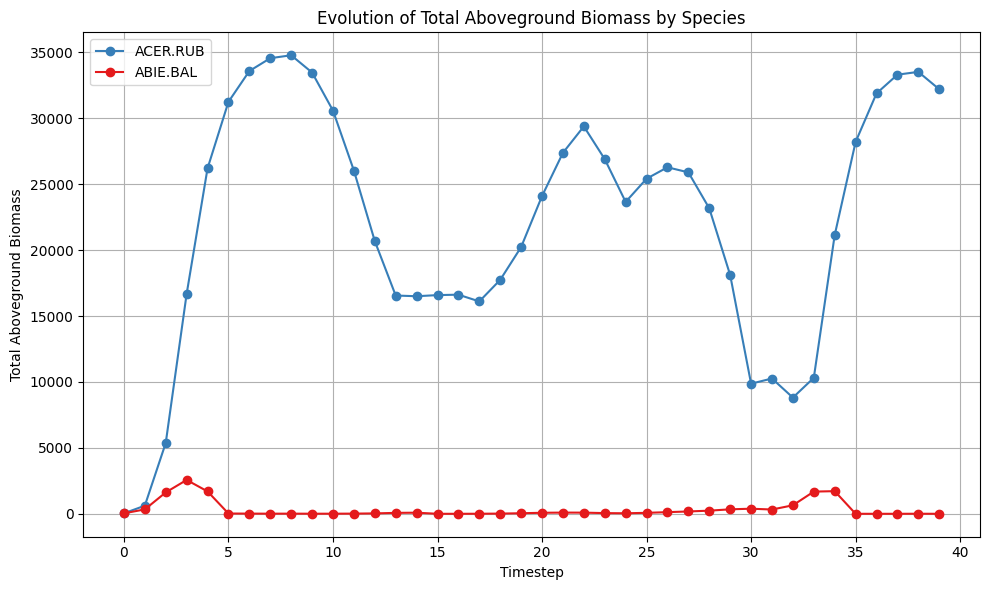


=== Competition Analysis: ABIE.BAL vs ACER.RUB ===



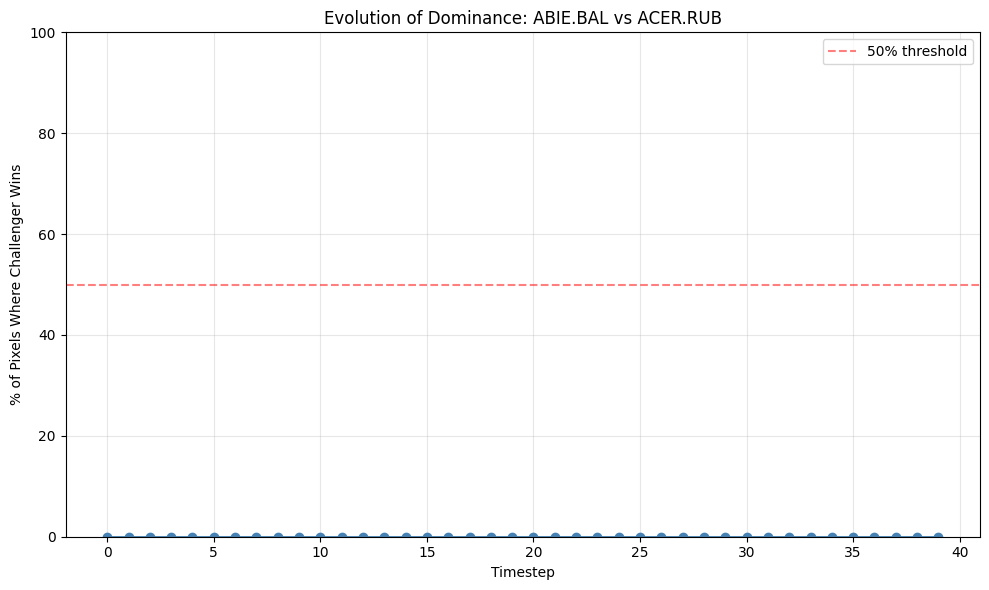

Method 1 - Absolute Biomass at End:
  ABIE.BAL wins in 0.00% of pixels
  (0 out of 1 pixels)

Method 2 - Relative Ratio Improvement:
  ABIE.BAL wins in 0.00% of pixels
  (0 out of 1 pixels)


In [10]:
# Now, we read the biomass rasters (wood + foliage)
import os
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from pathlib import Path

# Configuration
outputPath = "/tmp/TestScenarioPnET/output"  # Modify this path
challengingSpecies = "ABIE.BAL"  # Modify species name
opponentSpecies = "ACER.RUB"  # Modify species name

# Detect species folders
wood_biomass_path = os.path.join(outputPath, "WoodBiomass")
foliage_biomass_path = os.path.join(outputPath, "FoliageBiomass")

species_folders = [f for f in os.listdir(wood_biomass_path) 
                   if os.path.isdir(os.path.join(wood_biomass_path, f)) and f != "AllSpecies"]

print(f"Detected species: {species_folders}")

# Function to get sorted raster files
def get_raster_files(base_path, species, biomass_type):
    species_path = os.path.join(base_path, species)
    files = [f for f in os.listdir(species_path) if f.endswith('.img')]
    # Sort by timestep number
    files.sort(key=lambda x: int(x.split('-')[1].split('.')[0]))
    return [os.path.join(species_path, f) for f in files]

# Compute total biomass evolution for each species
biomass_evolution = {}

for species in species_folders:
    wood_files = get_raster_files(wood_biomass_path, species, "WoodBiomass")
    foliage_files = get_raster_files(foliage_biomass_path, species, "FoliageBiomass")

    total_biomass = []

    for wood_file, foliage_file in zip(wood_files, foliage_files):
        with rasterio.open(wood_file) as wood_src:
            wood_data = wood_src.read(1)
        with rasterio.open(foliage_file) as foliage_src:
            foliage_data = foliage_src.read(1)

        # Sum wood and foliage, then sum across all pixels
        total = np.nansum(wood_data + foliage_data)
        total_biomass.append(total)

    biomass_evolution[species] = total_biomass

# Plot biomass evolution
plt.figure(figsize=(10, 6))
for species, biomass in biomass_evolution.items():
    timesteps = list(range(len(biomass)))
    plt.plot(timesteps, biomass, marker='o', label=species, color=color_map[species])

plt.xlabel('Timestep')
plt.ylabel('Total Aboveground Biomass')
plt.title('Evolution of Total Aboveground Biomass by Species')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Competition analysis between challenging and opponent species
print(f"\n=== Competition Analysis: {challengingSpecies} vs {opponentSpecies} ===\n")

# Get files for both species
challenger_wood = get_raster_files(wood_biomass_path, challengingSpecies, "WoodBiomass")
challenger_foliage = get_raster_files(foliage_biomass_path, challengingSpecies, "FoliageBiomass")
opponent_wood = get_raster_files(wood_biomass_path, opponentSpecies, "WoodBiomass")
opponent_foliage = get_raster_files(foliage_biomass_path, opponentSpecies, "FoliageBiomass")

# Track win percentage over time
timesteps = []
win_percentages = []

for i, (c_wood, c_foliage, o_wood, o_foliage) in enumerate(zip(challenger_wood, challenger_foliage, 
                                                                 opponent_wood, opponent_foliage)):
    with rasterio.open(c_wood) as src:
        challenger_wood_data = src.read(1)
    with rasterio.open(c_foliage) as src:
        challenger_foliage_data = src.read(1)
    with rasterio.open(o_wood) as src:
        opponent_wood_data = src.read(1)
    with rasterio.open(o_foliage) as src:
        opponent_foliage_data = src.read(1)

    challenger_biomass = challenger_wood_data + challenger_foliage_data
    opponent_biomass = opponent_wood_data + opponent_foliage_data

    # Calculate win percentage
    win_mask = challenger_biomass > opponent_biomass
    valid_pixels = ~np.isnan(challenger_biomass) & ~np.isnan(opponent_biomass)
    win_count = np.sum(win_mask & valid_pixels)
    total_pixels = np.sum(valid_pixels)
    win_pct = (win_count / total_pixels) * 100 if total_pixels > 0 else 0

    timesteps.append(i)
    win_percentages.append(win_pct)

# Plot win percentage evolution
plt.figure(figsize=(10, 6))
plt.plot(timesteps, win_percentages, marker='o', linewidth=2, color='steelblue')
plt.xlabel('Timestep')
plt.ylabel('% of Pixels Where Challenger Wins')
plt.title(f'Evolution of Dominance: {challengingSpecies} vs {opponentSpecies}')
plt.grid(True, alpha=0.3)
plt.ylim(0, 100)
plt.axhline(y=50, color='red', linestyle='--', alpha=0.5, label='50% threshold')
plt.legend()
plt.tight_layout()
plt.show()

# Load first timestep (beginning)
with rasterio.open(challenger_wood[0]) as src:
    challenger_wood_start = src.read(1)
with rasterio.open(challenger_foliage[0]) as src:
    challenger_foliage_start = src.read(1)
with rasterio.open(opponent_wood[0]) as src:
    opponent_wood_start = src.read(1)
with rasterio.open(opponent_foliage[0]) as src:
    opponent_foliage_start = src.read(1)

challenger_biomass_start = challenger_wood_start + challenger_foliage_start
opponent_biomass_start = opponent_wood_start + opponent_foliage_start

# Load last timestep (end)
with rasterio.open(challenger_wood[-1]) as src:
    challenger_wood_end = src.read(1)
with rasterio.open(challenger_foliage[-1]) as src:
    challenger_foliage_end = src.read(1)
with rasterio.open(opponent_wood[-1]) as src:
    opponent_wood_end = src.read(1)
with rasterio.open(opponent_foliage[-1]) as src:
    opponent_foliage_end = src.read(1)

challenger_biomass_end = challenger_wood_end + challenger_foliage_end
opponent_biomass_end = opponent_wood_end + opponent_foliage_end

# Method 1: Absolute biomass comparison at end
win_absolute = challenger_biomass_end > opponent_biomass_end
total_pixels = np.sum(~np.isnan(challenger_biomass_end) & ~np.isnan(opponent_biomass_end))
win_count_absolute = np.sum(win_absolute)
win_percentage_absolute = (win_count_absolute / total_pixels) * 100

print(f"Method 1 - Absolute Biomass at End:")
print(f"  {challengingSpecies} wins in {win_percentage_absolute:.2f}% of pixels")
print(f"  ({win_count_absolute} out of {total_pixels} pixels)\n")

# Method 2: Relative ratio improvement
# Calculate ratio at start and end (challenger / opponent)
# Avoid division by zero
epsilon = 1e-10
ratio_start = challenger_biomass_start / (opponent_biomass_start + epsilon)
ratio_end = challenger_biomass_end / (opponent_biomass_end + epsilon)

# Challenger wins if ratio increased
win_relative = ratio_end > ratio_start
valid_pixels = ~np.isnan(ratio_start) & ~np.isnan(ratio_end) & np.isfinite(ratio_start) & np.isfinite(ratio_end)
win_count_relative = np.sum(win_relative & valid_pixels)
total_valid_pixels = np.sum(valid_pixels)
win_percentage_relative = (win_count_relative / total_valid_pixels) * 100

print(f"Method 2 - Relative Ratio Improvement:")
print(f"  {challengingSpecies} wins in {win_percentage_relative:.2f}% of pixels")
print(f"  ({win_count_relative} out of {total_valid_pixels} pixels)")

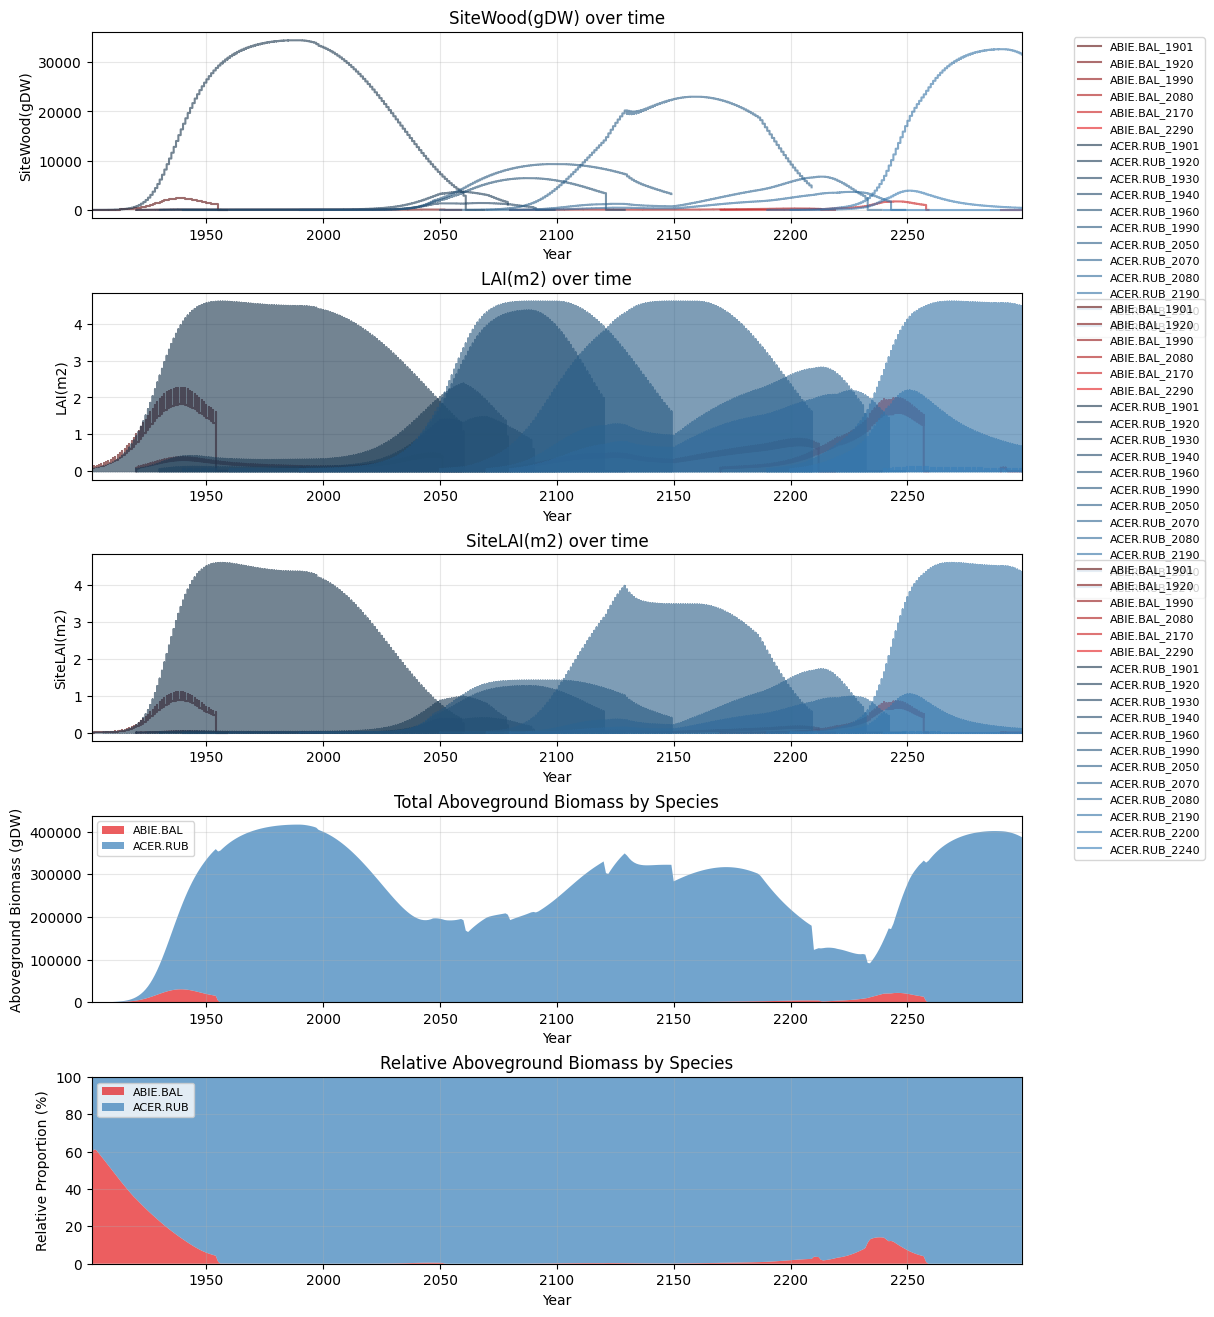

,Time,Year,Month,Age(yr),TopLayer(-),CanopyLayerProp,CanopyGrowingSpace,LAI(m2),SiteLAI(m2),GrossPsn(gC_m2_mo),...,AdjFolN(gN_gC),AdjFracFol(-),CiModifier(-),AdjHalfSat,LimitingFactor,Unnamed: 39,Cohort,Species,ImplantYear,AbovegroundBiomass_InSite
0,2080.00,2080,1,1,0,0.022643,1.0,0.00000,0.000000,0.000000,...,1.0,0.055000,1,134,fTemp,NaN,ABIE.BAL_2080,ABIE.BAL,2080,4.120947
1,2080.08,2080,2,1,0,0.022643,1.0,0.00000,0.000000,0.000000,...,1.0,0.055000,1,134,fTemp,NaN,ABIE.BAL_2080,ABIE.BAL,2080,4.120947
2,2080.17,2080,3,1,0,0.022643,1.0,0.00000,0.000000,0.000000,...,1.0,0.055000,1,134,fTemp,NaN,ABIE.BAL_2080,ABIE.BAL,2080,4.120947
3,2080.25,2080,4,1,0,0.020226,1.0,0.09408,0.001903,3.826343,...,1.0,0.070000,1,134,fRad,NaN,ABIE.BAL_2080,ABIE.BAL,2080,3.957145
4,2080.33,2080,5,1,0,0.020226,1.0,0.09408,0.001903,4.332309,...,1.0,0.070000,1,134,fRad,NaN,ABIE.BAL_2080,ABIE.BAL,2080,3.957145
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24811,2259.58,2259,8,90,0,0.000000,1.0,0.00000,0.000000,0.000000,...,1.0,0.055033,1,134,fRad,NaN,ABIE.BAL_2170,ABIE.BAL,2170,0.000000
24812,2259.67,2259,9,90,0,0.000000,1.0,0.00000,0.000000,0.000000,...,1.0,0.055033,1,134,fRad,NaN,ABIE.BAL_2170,ABIE.BAL,2170,0.000000
24813,2259.75,2259,10,90,0,0.000000,1.0,0.00000,0.000000,0.000000,...,1.0,0.055033,1,134,fRad,NaN,ABIE.BAL_2170,ABIE.BAL,2170,0.000000
24814,2259.83,2259,11,90,0,0.000000,1.0,0.00000,0.000000,0.000000,...,1.0,0.055033,1,134,fTemp,NaN,ABIE.BAL_2170,ABIE.BAL,2170,0.000000


In [11]:
from functionsForCalibration import *

plot_all_cohort_results("/tmp/TestScenarioPnET/Output/Site1", color_map)

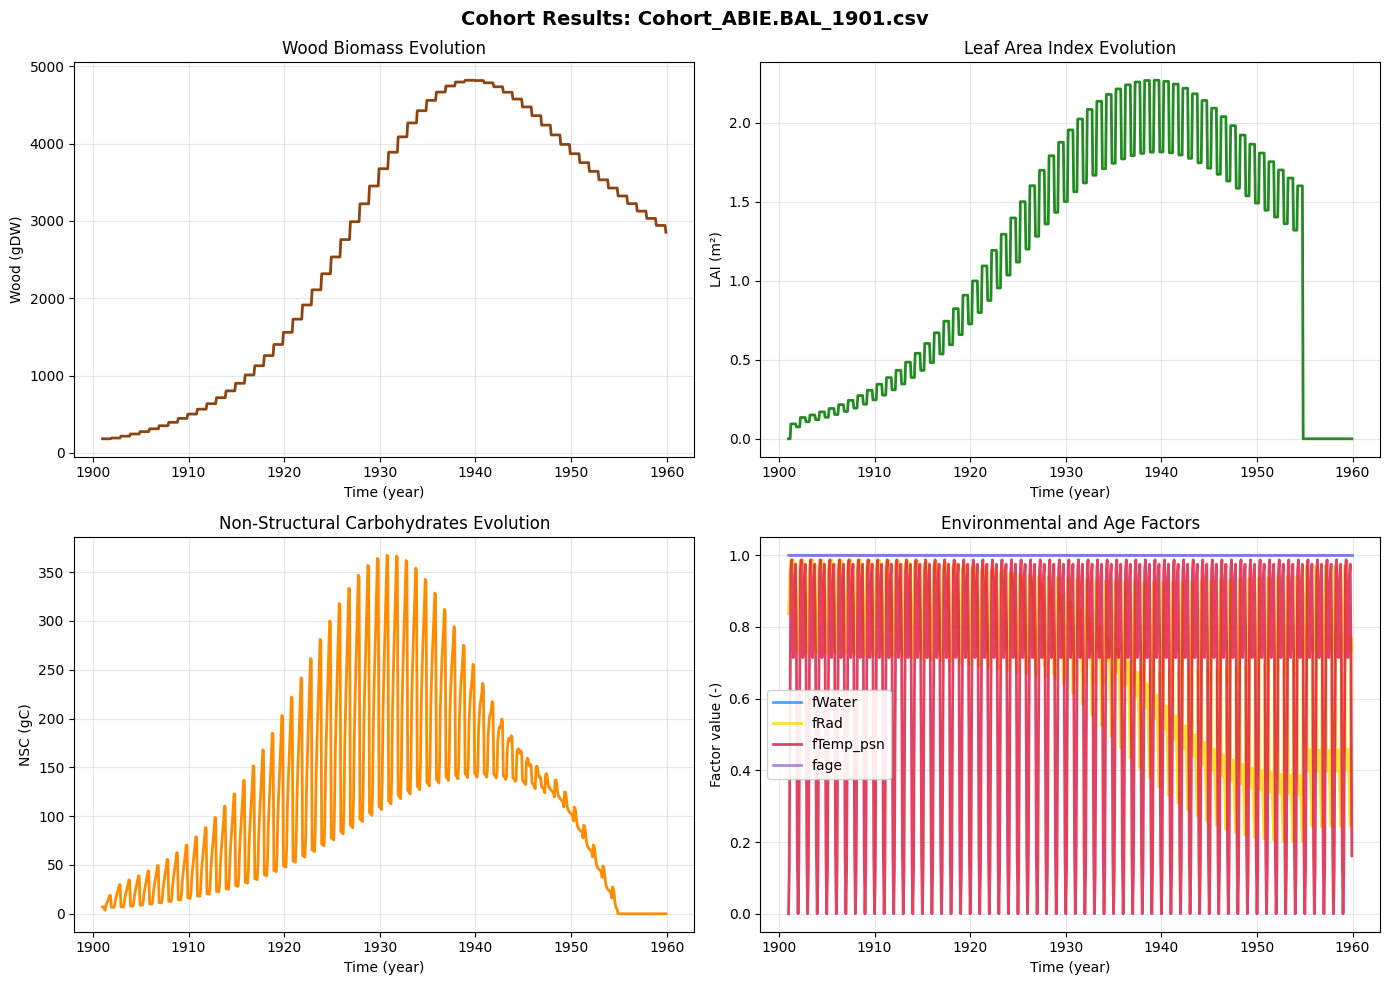

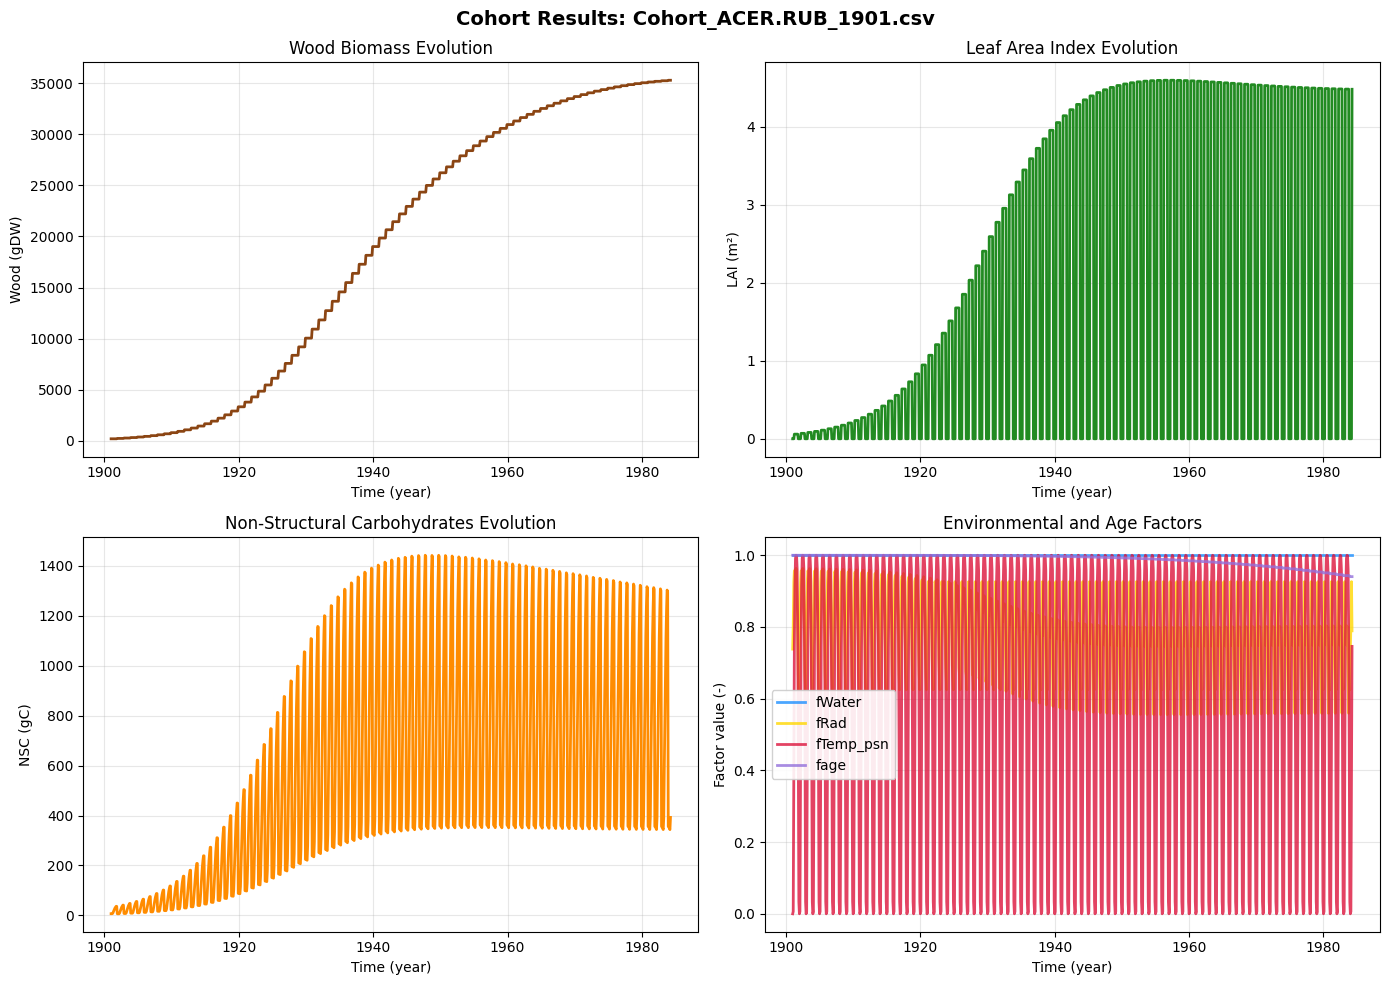

In [12]:
from functionsForCalibration import *

plot_single_cohort_results("/tmp/TestScenarioPnET/Output/Site1/Cohort_ABIE.BAL_1901.csv", monthsToKeep = 1000)
plot_single_cohort_results("/tmp/TestScenarioPnET/Output/Site1/Cohort_ACER.RUB_1901.csv", monthsToKeep = 1000)



Add a check for wood at age 14 for species competition on newly disturbed sites, as recommanded by Gustafson ?

In [23]:
import math

mainLayerPAR = 800
LAISummed = 5
LAIIndex = 4
k = 0.58 # 0.5 or 0.58 (abies or acer)

print(mainLayerPAR * math.exp(-k * (LAISummed - LAIIndex)))

447.91869325232165


In [22]:
import math

mainLayerPAR = 800
LAISummed = 5
LAIIndex = 4
k = 0.50 # 0.5 or 0.58 (abies or acer)

print(mainLayerPAR * math.exp(-k * (LAISummed - LAIIndex)))

485.22452777010676
